# Day 08. Exercise 02
# Multiclass classification. One-hot encoding. Random forest

## 0. Imports

In [1]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn import tree
from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings('ignore')
pd.options.display.max_rows = 10

## 1. Preprocessing

1. Read the file [`checker-submits.csv`](https://drive.google.com/file/d/14voc4fNJZiLEFaZyd8nEG-lQt5JjatYw/view?usp=sharing).
2. Create a dataframe `df` with the columns: `uid`, `labname`, `numTrials`, `hour`, `dayofweek` where `hour` is extracted from the `timestamp` as well as the `dayofweek` (`0` is Monday, `6` is Sunday). We will try to predict the day of the week having data about which user made a commit for which lab at which hour and which try it was.
3. Using `OneHotEncoder()` transform your categorical features, delete from the dataframe the initial columns.
4. Use `StandardScaler()` and scale your continuous features.
5. Save the dataframe as `dayofweek.csv`.
6. Before trying out different algorithms, find out the accuracy of the naive algorithms – the one that predicts everything as the most popular class.

In [2]:
df = pd.read_csv('../data/checker_submits.csv', parse_dates=['timestamp'])
df['hour'] = df['timestamp'].dt.hour 
df['dayofweek'] = df['timestamp'].dt.weekday
del df['timestamp']
df

,uid,labname,numTrials,hour,dayofweek
0,user_4,project1,1,5,4
1,user_4,project1,2,5,4
2,user_4,project1,3,5,4
3,user_4,project1,4,5,4
4,user_4,project1,5,5,4
...,...,...,...,...,...
1681,user_19,laba06s,9,20,3
1682,user_1,laba06s,6,20,3
1683,user_1,laba06s,7,20,3
1684,user_1,laba06s,8,20,3


In [3]:
enc = OneHotEncoder(handle_unknown='ignore')
enc.fit(df[['uid', 'labname']])
categorical_data = enc.transform(df[['uid', 'labname']]).toarray()
categorical_inames = [y for x in enc.categories_ for y in x]
categorical_data = pd.DataFrame(categorical_data, columns=categorical_inames)
categorical_data

,user_0,user_1,user_10,user_11,user_12,user_13,user_14,user_15,user_16,user_17,...,lab02,lab03,lab03s,lab05s,laba04,laba04s,laba05,laba06,laba06s,project1
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1681,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1682,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1683,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1684,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [4]:
scaler = StandardScaler()
# fit and transform the data != fit_transform
scaled_data = scaler.fit(df[['numTrials', 'hour']])
numeric_data = scaled_data.transform(df[['numTrials', 'hour']])
numeric_data = pd.DataFrame(numeric_data, columns=['numTrials', 'hour'])
numeric_data

,numTrials,hour
0,-0.788667,-2.562352
1,-0.756764,-2.562352
2,-0.724861,-2.562352
3,-0.692958,-2.562352
4,-0.661055,-2.562352
...,...,...
1681,-0.533442,0.945382
1682,-0.629151,0.945382
1683,-0.597248,0.945382
1684,-0.565345,0.945382


In [5]:
agg_df = pd.concat([categorical_data, numeric_data, df['dayofweek']], axis=1)
agg_df

,user_0,user_1,user_10,user_11,user_12,user_13,user_14,user_15,user_16,user_17,...,lab05s,laba04,laba04s,laba05,laba06,laba06s,project1,numTrials,hour,dayofweek
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.788667,-2.562352,4
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.756764,-2.562352,4
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.724861,-2.562352,4
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.692958,-2.562352,4
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.661055,-2.562352,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1681,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.533442,0.945382,3
1682,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.629151,0.945382,3
1683,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.597248,0.945382,3
1684,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.565345,0.945382,3


In [6]:
agg_df.to_csv('../data/dayofweek.csv', index=False)

In [7]:
y_train = agg_df['dayofweek']
naive_pred = pd.DataFrame([[agg_df['dayofweek'].mode()[0]] for _ in range(agg_df.shape[0])])
acc = accuracy_score(naive_pred, y_train)
acc

0.23487544483985764

## 2. Algorithms

### a. Logreg

1. Train logistic regression, for the baseline model use `random_state=21`, `fit_intercept=False`. 
2. Calculate the accuracy.
3. Write a function that draws the plot (`barh`) taking coefficients of any trained models, names of the features and the number of `top-n` most important features to display.
4. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model.
5. Remember that it is a multiclass classification and `coef_` returns a matrix, to calculate importance for a feature you need to sum all the individual feature importances for all the target values.

In [8]:
df = pd.read_csv('../data/dayofweek.csv')
y_train = df['dayofweek']
X_train = df.drop('dayofweek', axis=1)
features_names = X_train.columns

log_reg = LogisticRegression(random_state=21, fit_intercept=False, solver='liblinear')
log_reg.fit(X_train, y_train)

predict_col = log_reg.predict(X_train)

In [9]:
acc = accuracy_score(predict_col, y_train)
acc

0.6215895610913404

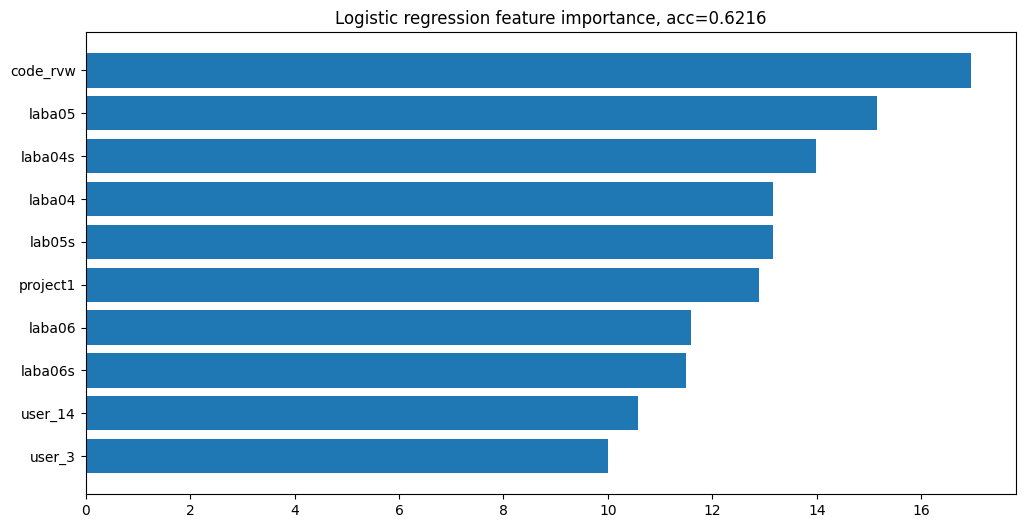

In [10]:
#  get coefs of all targets (model.coef_ len = 7), coefs should be compared by absolute value
logreg_coef = [sum(abs(log_reg.coef_[y][x]) for y in range(len(log_reg.coef_))) for x in range(len(log_reg.coef_[0]))]


def plot_importance(coef: list[int | float], names: list[str], n_top: int, model_name: str, acc: float) -> None:
    features_names = X_train.columns
    
    coef = [(features_names[num], x) for num, x in enumerate(coef)]
    coef = sorted(coef, key=lambda x : x[1], reverse=True)
    names, coef = [x[0] for x in coef], [x[1] for x in coef]

    plt.figure(figsize=(12, 6))
    plt.barh(range(len(names))[:n_top], coef[:n_top][::-1], align='center')
    plt.yticks(range(len(names[:n_top])), labels=names[:n_top][::-1])

    plt.title(f'{model_name} feature importance, {acc=}')
    plt.show()


plot_importance(logreg_coef, features_names, 10, 'Logistic regression', round(acc, 4))

### b. SVC

1. Train a `SVC` model, for the baseline model use parameters `kernel='linear'`, `probability=True`, `random_state=21`. 
2. Try different kernels, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model for the linear kernel *

*By default SVC uses “one vs one” strategy of the classification, thus in `coef_` it returns a matrix. To calculate importance for a feature you need to use [OneVsRestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.multiclass.OneVsRestClassifier.html) over the SVC and sum all the individual feature importances for all the target values.

In [11]:
for name in ['sigmoid', 'rbf', 'poly', 'linear']:
    svc = OneVsRestClassifier(SVC(random_state=21, probability=True, kernel=name)).fit(X_train, y_train)
    svc.fit(X_train, y_train)
    predict_col = svc.predict(X_train)
    acc = accuracy_score(predict_col, y_train)
    print(name, acc)

sigmoid 0.3499406880189798
rbf 0.8641755634638197
poly 0.8653618030842231
linear 0.6126927639383155


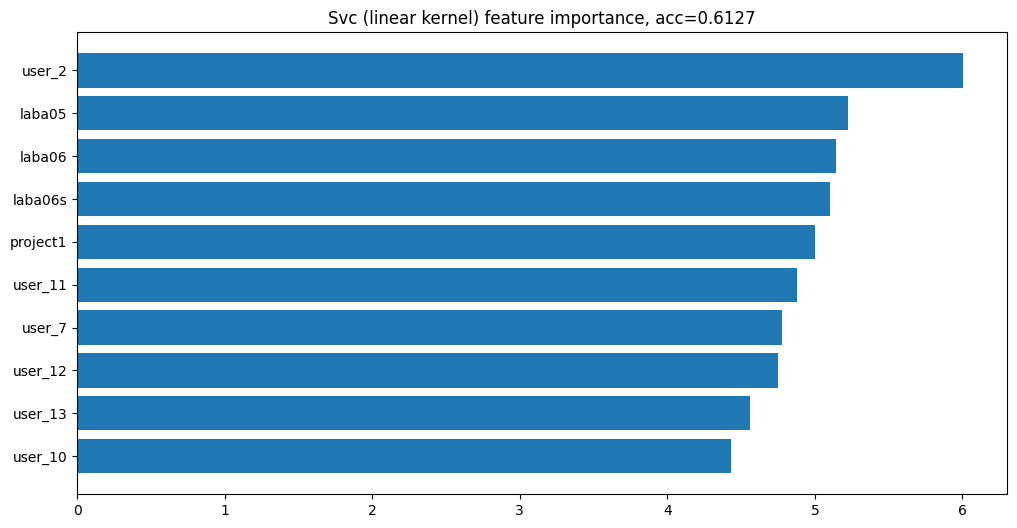

In [12]:
svc_coef = [svc.estimators_[x].coef_[0]  for x in range(7)]
svc_coef = [sum(abs(svc_coef[y][x]) for y in range(len(svc_coef))) for x in range(len(svc_coef[0]))]

plot_importance(svc_coef, features_names, 10, 'Svc (linear kernel)', round(acc, 4))

### c. Decision tree

1. Train a `DecisionTreeClassifier` using for the baseline model `max_depth=4`, `random_state=21`. 
2. Try different values of `max_depth`, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model using the written function.

In [13]:
for x in range(1, 5):
    dec_tree_class = tree.DecisionTreeClassifier(random_state=42, max_depth=x).fit(X_train.values, y_train.values)
    predict = dec_tree_class.predict(X_train.values)
    acc = accuracy_score(predict, y_train)
    print(acc)

0.35765124555160144
0.4389086595492289
0.48991696322657174
0.5516014234875445


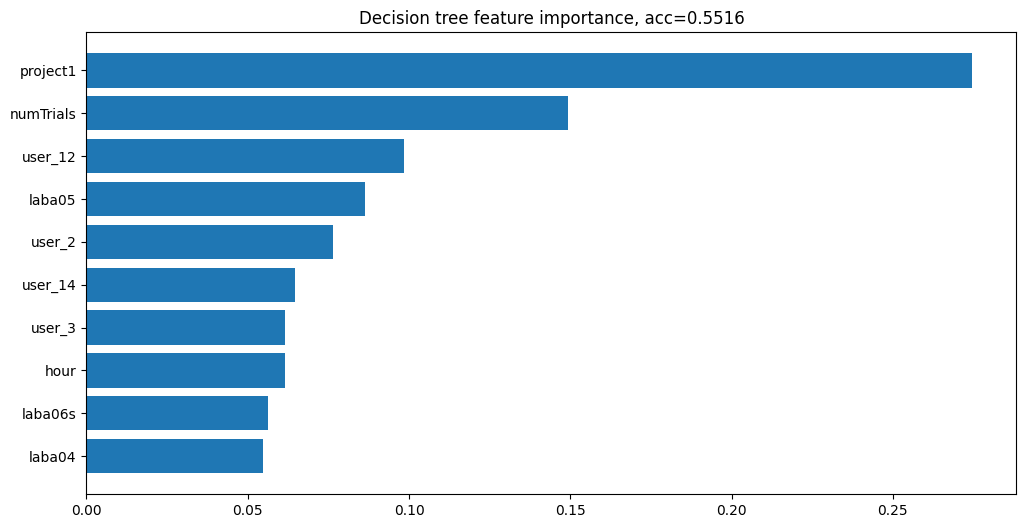

In [14]:
plot_importance(dec_tree_class.feature_importances_, features_names, 10, 'Decision tree', round(acc, 4))

### d. Random forest

In real life forest is a set of trees. The same thing is with machine learning. Random forest is a set of individual decision trees (check the documentation for more details).

1. Train a `RandomForestClassifier` using for the baseline model parameters `n_estimators=100`, `max_depth = 25`, `random_state=21`. 
2. Try different values of `max_depth` and `n_estimators`, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model using the written function.

In [15]:
for depth in range(5, 26, 5):
    for estimators in range(25, 101, 25):
        random_forest = RandomForestClassifier(random_state=21, max_depth=depth, n_estimators=estimators).fit(X_train.values, y_train.values)
        predict = random_forest.predict(X_train.values)
        acc = accuracy_score(predict, y_train)
        print(f'{depth=} {estimators=} acc=', acc)

depth=5 estimators=25 acc= 0.6269276393831554
depth=5 estimators=50 acc= 0.6198102016607354
depth=5 estimators=75 acc= 0.6281138790035588
depth=5 estimators=100 acc= 0.6429418742586003
depth=10 estimators=25 acc= 0.872479240806643
depth=10 estimators=50 acc= 0.8795966785290629
depth=10 estimators=75 acc= 0.8801897983392646
depth=10 estimators=100 acc= 0.8701067615658363
depth=15 estimators=25 acc= 0.9744958481613286
depth=15 estimators=50 acc= 0.9798339264531435
depth=15 estimators=75 acc= 0.9792408066429419
depth=15 estimators=100 acc= 0.9804270462633452
depth=20 estimators=25 acc= 0.9958481613285883
depth=20 estimators=50 acc= 0.9976275207591934
depth=20 estimators=75 acc= 0.99644128113879
depth=20 estimators=100 acc= 0.9976275207591934
depth=25 estimators=25 acc= 0.9994068801897983
depth=25 estimators=50 acc= 0.9994068801897983
depth=25 estimators=75 acc= 0.9994068801897983
depth=25 estimators=100 acc= 0.9988137603795967


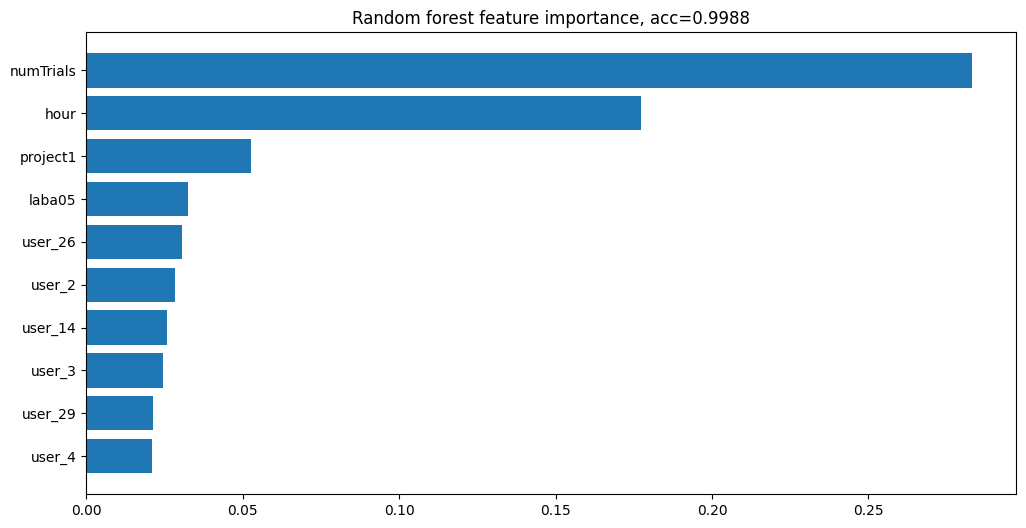

In [16]:
plot_importance(random_forest.feature_importances_, features_names, 10, 'Random forest', round(acc, 4))